# 03 — Análisis: N/Z vs modo dominante

**Pregunta:** ¿Cómo se relaciona la razón $N/Z$ con el modo de desintegración dominante ($\beta^-$ frente a $\beta^+$/EC) en los estados base?

**Hilo conductor (lo que queremos concluir):**

1. En $Z$ pequeños, los **estables** tienen $N/Z \sim 1$ (casi tantos neutrones como protones).
2. Al subir $Z$, esa razón **crece** por la **repulsión electrostática** (Coulomb): hacen falta más neutrones relativos.
3. A $Z$ muy grandes **deja de haber** nuclidos estables (solo $\beta$, $\alpha$, …).

Consultas: `sql/queries.sql`. Filtro: `level_index = 0`. Las secciones 1–5 aportan evidencia; la **§6** cierra con esas tres ideas.


In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path("..").resolve()
if not (ROOT / "sql" / "queries.sql").exists():
    ROOT = Path(".").resolve()
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

host = os.getenv("MYSQL_HOST", "127.0.0.1")
url = (
    f"mysql+pymysql://{os.getenv('MYSQL_USER','nudat')}:"
    f"{os.getenv('MYSQL_PASSWORD','nudat')}@{host}:"
    f"{os.getenv('MYSQL_PORT','3306')}/{os.getenv('MYSQL_DATABASE','nudat')}"
)
engine = create_engine(url, pool_pre_ping=True)
with engine.connect() as conn:
    print(conn.execute(text("SELECT DATABASE(), USER()")).fetchone())
    print("Tables:", [r[0] for r in conn.execute(text("SHOW TABLES")).fetchall()])


('nudat', 'nudat@172.19.0.1')
Tables: ['decay_channel', 'element', 'nuclear_state', 'nuclide']


## 1. ⟨N/Z⟩ por modo dominante (JOIN + GROUP BY)


In [3]:
modes = pd.read_sql(text('''
SELECT
  ns.dominant_mode,
  COUNT(*) AS n_nuclides,
  ROUND(AVG(n.N / NULLIF(n.Z, 0)), 3) AS mean_N_over_Z,
  ROUND(STDDEV_SAMP(n.N / NULLIF(n.Z, 0)), 3) AS sd_N_over_Z
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
WHERE ns.level_index = 0
GROUP BY ns.dominant_mode
ORDER BY n_nuclides DESC
'''), engine)
modes


,dominant_mode,n_nuclides,mean_N_over_Z,sd_N_over_Z
0,B-,1378,1.609,0.185
1,EC_BP,1096,1.206,0.186
2,ALPHA,465,1.402,0.133
3,STABLE,253,1.306,0.174
4,OTHER,179,1.407,0.790


### Interpretación

Orden global: ⟨N/Z⟩($B-$) > ⟨N/Z⟩(STABLE) > ⟨N/Z⟩(EC_BP). Eso sitúa a los estables **en el medio** del valle. Cómo cambia ese “medio” con $Z$ se ve en la §3 (frontera) y se resume en la §6.


In [4]:
minmax = pd.read_sql(text('''
SELECT
  ns.dominant_mode,
  ROUND(MIN(n.N / NULLIF(n.Z, 0)), 3) AS min_nz,
  ROUND(AVG(n.N / NULLIF(n.Z, 0)), 3) AS mean_nz,
  ROUND(MAX(n.N / NULLIF(n.Z, 0)), 3) AS max_nz,
  COUNT(*) AS n
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
WHERE ns.level_index = 0
  AND ns.dominant_mode IN ('B-', 'EC_BP', 'STABLE')
GROUP BY ns.dominant_mode
ORDER BY mean_nz DESC
'''), engine)
minmax


,dominant_mode,min_nz,mean_nz,max_nz,n
0,B-,1.105,1.609,3.000,1378
1,STABLE,0.000,1.306,1.550,253
2,EC_BP,0.500,1.206,1.545,1096


## 2. Chart N–Z coloreado por modo


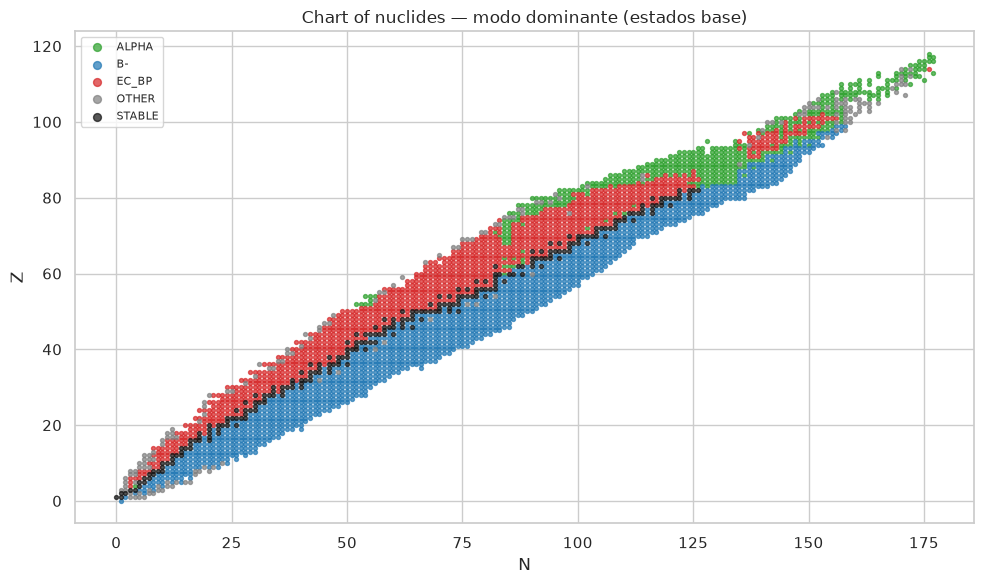

In [5]:
chart = pd.read_sql(text('''
SELECT n.Z, n.N, n.A, n.name,
       n.N / NULLIF(n.Z, 0) AS N_over_Z,
       ns.dominant_mode, ns.is_stable
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
WHERE ns.level_index = 0
'''), engine)

palette = {
    "B-": "#1f77b4", "EC_BP": "#d62728", "ALPHA": "#2ca02c",
    "STABLE": "#111111", "IT": "#9467bd", "OTHER": "#7f7f7f", "UNKNOWN": "#c7c7c7",
}
fig, ax = plt.subplots(figsize=(10, 6))
for mode, sub in chart.groupby("dominant_mode"):
    ax.scatter(sub["N"], sub["Z"], s=8, alpha=0.7, label=mode, c=palette.get(mode, "#aaa"))
ax.set_xlabel("N"); ax.set_ylabel("Z")
ax.set_title("Chart of nuclides — modo dominante (estados base)")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "03_chart_modos.png", dpi=130)
plt.show()


### Interpretación

Vista espacial del valle: $\beta^-$ a la derecha (rico en $N$), EC/$\beta^+$ a la izquierda, **STABLE** en la franja central. A $Z$ altos la franja negra se **adelgaza y desaparece** — anticipo de la conclusión 3.


## 3. Frontera ⟨N/Z⟩ por bins de Z


,Z_bin,mean_nz_B,mean_nz_STABLE,mean_nz_EC_BP,mean_nz_ALPHA,n_B,n_STABLE,n_EC_BP,n_ALPHA
0,0,1.886,1.005,0.755,1.000,49.0,17.0,12.0,1.0
1,10,1.675,1.096,0.844,NaN,146.0,23.0,45.0,0.0
2,20,1.591,1.175,0.963,NaN,170.0,29.0,81.0,0.0
3,30,1.580,1.266,1.064,NaN,179.0,31.0,110.0,0.0
4,40,1.582,1.286,1.107,NaN,226.0,34.0,126.0,0.0
5,50,1.605,1.384,1.210,1.026,181.0,41.0,166.0,8.0
6,60,1.575,1.434,1.250,1.324,144.0,33.0,190.0,13.0
7,70,1.581,1.479,1.319,1.205,121.0,32.0,192.0,47.0
8,80,1.620,1.508,1.383,1.378,113.0,13.0,103.0,162.0
9,90,1.594,NaN,1.488,1.459,49.0,0.0,56.0,119.0


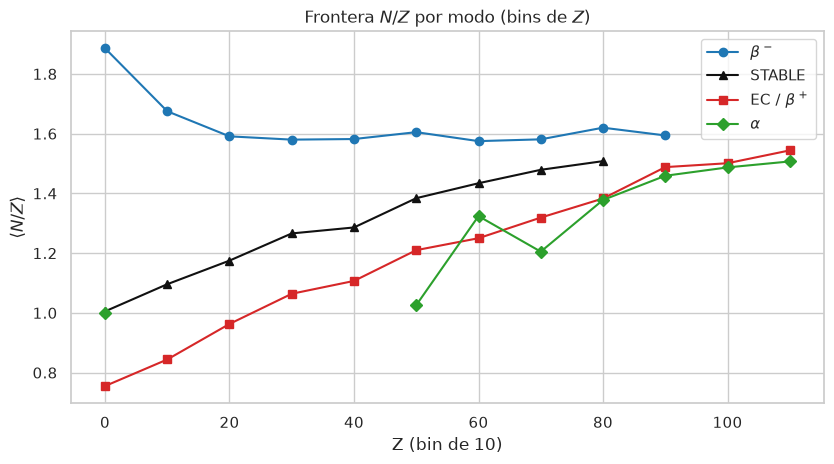

In [6]:
frontier = pd.read_sql(text("""
SELECT
  FLOOR(n.Z / 10) * 10 AS Z_bin,
  ROUND(AVG(CASE WHEN ns.dominant_mode = 'B-' THEN n.N / NULLIF(n.Z, 0) END), 3) AS mean_nz_B,
  ROUND(AVG(CASE WHEN ns.dominant_mode = 'STABLE' THEN n.N / NULLIF(n.Z, 0) END), 3) AS mean_nz_STABLE,
  ROUND(AVG(CASE WHEN ns.dominant_mode = 'EC_BP' THEN n.N / NULLIF(n.Z, 0) END), 3) AS mean_nz_EC_BP,
  ROUND(AVG(CASE WHEN ns.dominant_mode = 'ALPHA' THEN n.N / NULLIF(n.Z, 0) END), 3) AS mean_nz_ALPHA,
  SUM(ns.dominant_mode = 'B-') AS n_B,
  SUM(ns.dominant_mode = 'STABLE') AS n_STABLE,
  SUM(ns.dominant_mode = 'EC_BP') AS n_EC_BP,
  SUM(ns.dominant_mode = 'ALPHA') AS n_ALPHA
FROM nuclear_state ns
JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
WHERE ns.level_index = 0
  AND ns.dominant_mode IN ('B-', 'EC_BP', 'STABLE', 'ALPHA')
GROUP BY FLOOR(n.Z / 10) * 10
ORDER BY Z_bin
"""), engine)
display(frontier)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(frontier["Z_bin"], frontier["mean_nz_B"], "o-", label=r"$\beta^-$", color="#1f77b4")
ax.plot(frontier["Z_bin"], frontier["mean_nz_STABLE"], "^-", label="STABLE", color="#111111")
ax.plot(frontier["Z_bin"], frontier["mean_nz_EC_BP"], "s-", label=r"EC / $\beta^+$", color="#d62728")
ax.plot(frontier["Z_bin"], frontier["mean_nz_ALPHA"], "D-", label=r"$\alpha$", color="#2ca02c")
ax.set_xlabel("Z (bin de 10)")
ax.set_ylabel(r"$\langle N/Z \rangle$")
ax.set_title(r"Frontera $N/Z$ por modo (bins de $Z$)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "03_frontera_NZ.png", dpi=130)
plt.show()


### Interpretación → hacia las tres conclusiones

Mirar la columna STABLE (y su conteo) en la tabla de arriba:

1. **$Z$ bajos (bins 0–20):** ⟨N/Z⟩$\mathrm{STABLE} \approx 1.0$–$1.2$ → cerca de la paridad $N\approx Z$.
2. **Al subir $Z$:** ⟨N/Z⟩$\mathrm{STABLE}$ pasa a $\sim 1.4$–$1.5$ (bins 60–80). Las curvas $\beta^-$ y EC también suben: más Coulomb → más neutrones relativos.
3. **$Z \gtrsim 90$:** `mean_nz_STABLE` es NaN y $n_\mathrm{STABLE}=0$ → **ya no hay estables** en el snapshot; dominan EC/$\beta^+$, $\alpha$, etc.

La celda siguiente aísla solo el valle (STABLE) para fijar ese relato.


## 3a. El valle a lo largo de $Z$ (solo STABLE)

Evidencia directa de las conclusiones 1–3: ⟨N/Z⟩ y **número** de estados base estables por bin de $Z$.


,Z_bin,mean_nz_STABLE,n_STABLE
0,0,1.005,17.0
1,10,1.096,23.0
2,20,1.175,29.0
3,30,1.266,31.0
4,40,1.286,34.0
5,50,1.384,41.0
6,60,1.434,33.0
7,70,1.479,32.0
8,80,1.508,13.0
9,90,NaN,0.0


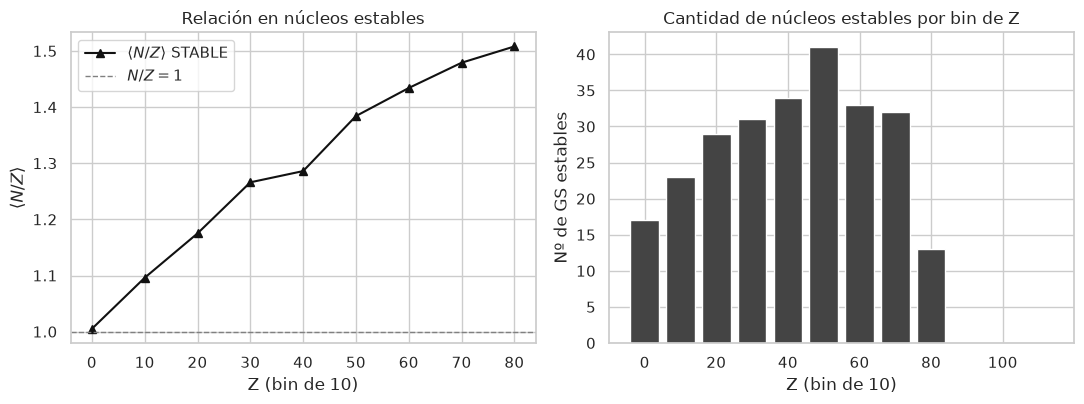

STABLE: ⟨N/Z⟩ de 1.005 (Z≈0) → 1.508 (Z≈80); último bin con estables: Z≈80


In [11]:
# Reusa la frontera ya calculada; añade conteo STABLE si faltara
stable_valley = frontier[["Z_bin", "mean_nz_STABLE", "n_STABLE"]].copy()
display(stable_valley)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(
    stable_valley["Z_bin"], stable_valley["mean_nz_STABLE"],
    "^-", color="#111111", label=r"$\langle N/Z\rangle$ STABLE",
)
axes[0].axhline(1.0, color="gray", ls="--", lw=1, label=r"$N/Z = 1$")
axes[0].set_xlabel("Z (bin de 10)")
axes[0].set_ylabel(r"$\langle N/Z\rangle$")
axes[0].set_title("Relación en núcleos estables")
axes[0].legend()

axes[1].bar(
    stable_valley["Z_bin"], stable_valley["n_STABLE"].fillna(0),
    width=8, color="#444444", align="center",
)
axes[1].set_xlabel("Z (bin de 10)")
axes[1].set_ylabel("Nº de GS estables")
axes[1].set_title("Cantidad de núcleos estables por bin de Z")

plt.tight_layout()
plt.savefig(FIG / "03_stable_valley.png", dpi=130)
plt.show()

last_stable = stable_valley.dropna(subset=["mean_nz_STABLE"])
if len(last_stable):
    print(
        f"STABLE: ⟨N/Z⟩ de {last_stable.iloc[0]['mean_nz_STABLE']:.3f} "
        f"(Z≈{int(last_stable.iloc[0]['Z_bin'])}) → "
        f"{last_stable.iloc[-1]['mean_nz_STABLE']:.3f} "
        f"(Z≈{int(last_stable.iloc[-1]['Z_bin'])}); "
        f"último bin con estables: Z≈{int(last_stable.iloc[-1]['Z_bin'])}"
    )


## 3b. ¿Por qué sube $N/Z$? Estimación Coulomb (LDM)

Apoyo a la **conclusión 2**. NuDat no exporta $E_C$; en gota líquida

$$E_C \propto \frac{Z(Z-1)}{A^{1/3}}.$$

Estimamos el factor con $Z$, $A$ de la BD.


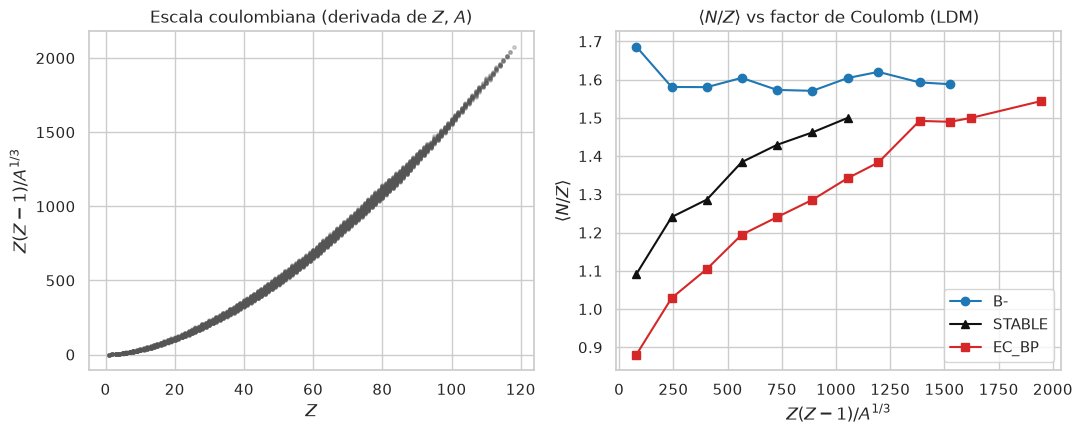

Ejemplo: media E_C estimada (MeV) por modo (GS)
               count   mean  median
dominant_mode                      
STABLE           253  342.4   325.6
B-              1377  360.7   300.1
EC_BP           1096  497.7   495.2


In [8]:
# Factor coulombiano LDM (adimensional / en unidades de la constante del modelo)
chart_c = chart.dropna(subset=["Z", "A", "N_over_Z"]).copy()
chart_c = chart_c[chart_c["A"] > 0]
chart_c["coulomb_factor"] = chart_c["Z"] * (chart_c["Z"] - 1) / np.power(chart_c["A"], 1.0 / 3.0)
# Constante LDM típica ~0.715 MeV → estimación en MeV (orden de magnitud)
chart_c["E_C_MeV_est"] = 0.715 * chart_c["coulomb_factor"]

sub = chart_c[chart_c["dominant_mode"].isin(["B-", "EC_BP", "STABLE"])].copy()
sub["C_bin"] = pd.cut(sub["coulomb_factor"], bins=12)

agg = (
    sub.groupby(["C_bin", "dominant_mode"], observed=True)["N_over_Z"]
    .mean()
    .unstack()
)
centers = sub.groupby("C_bin", observed=True)["coulomb_factor"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# (1) factor vs Z (muestra que Coulomb ~ crece con Z)
axes[0].scatter(chart_c["Z"], chart_c["coulomb_factor"], s=6, alpha=0.25, c="#555")
axes[0].set_xlabel("$Z$")
axes[0].set_ylabel(r"$Z(Z-1)/A^{1/3}$")
axes[0].set_title("Escala coulombiana (derivada de $Z$, $A$)")

# (2) ⟨N/Z⟩ vs factor, por modo
for mode, color, marker in [
    ("B-", "#1f77b4", "o"),
    ("STABLE", "#111111", "^"),
    ("EC_BP", "#d62728", "s"),
]:
    if mode in agg.columns:
        axes[1].plot(centers, agg[mode], marker + "-", color=color, label=mode)

axes[1].set_xlabel(r"$Z(Z-1)/A^{1/3}$")
axes[1].set_ylabel(r"$\langle N/Z \rangle$")
axes[1].set_title(r"$\langle N/Z \rangle$ vs factor de Coulomb (LDM)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "03_coulomb_NZ.png", dpi=130)
plt.show()

print("Ejemplo: media E_C estimada (MeV) por modo (GS)")
print(
    sub.groupby("dominant_mode")["E_C_MeV_est"]
    .agg(["count", "mean", "median"])
    .round(1)
    .sort_values("mean")
)


## 4. Distribución de $N/Z$ (apoyo)

Complemento: las tres familias se solapan poco en $N/Z$. No sustituye a la §3a para el relato en $Z$.


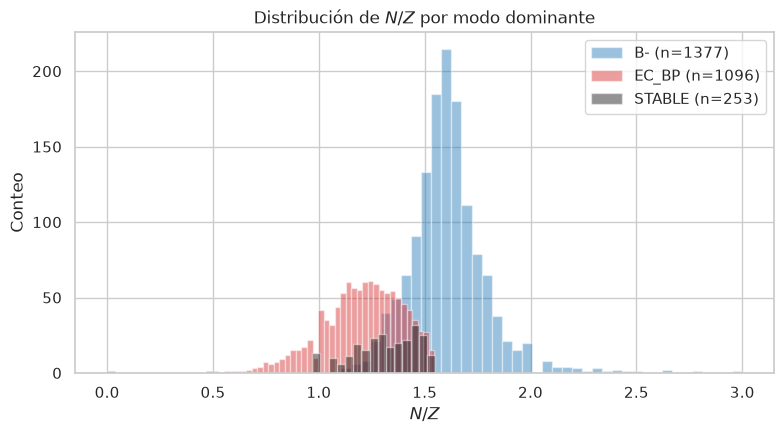

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for mode, color in [("B-", "#1f77b4"), ("EC_BP", "#d62728"), ("STABLE", "#111111")]:
    sub = chart.loc[chart["dominant_mode"] == mode, "N_over_Z"].dropna()
    ax.hist(sub, bins=40, alpha=0.45, label=f"{mode} (n={len(sub)})", color=color)
ax.set_xlabel(r"$N/Z$"); ax.set_ylabel("Conteo")
ax.set_title(r"Distribución de $N/Z$ por modo dominante")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "03_NZ_hist.png", dpi=120)
plt.show()


## 5. Modo mayoritario por bin de $Z$ (opcional)

¿Qué modo domina en cada franja? A $Z$ altos deja de ganar STABLE — coherente con la conclusión 3.


In [10]:
maj = pd.read_sql(text('''
SELECT
  t.Z_bin,
  t.dominant_mode AS majority_mode,
  t.n AS n_in_mode,
  t.mean_nz
FROM (
  SELECT
    FLOOR(n.Z / 10) * 10 AS Z_bin,
    ns.dominant_mode,
    COUNT(*) AS n,
    ROUND(AVG(n.N / NULLIF(n.Z, 0)), 3) AS mean_nz
  FROM nuclear_state ns
  JOIN nuclide n ON n.nuclide_id = ns.nuclide_id
  WHERE ns.level_index = 0
    AND ns.dominant_mode IN ('B-', 'EC_BP', 'STABLE', 'ALPHA', 'OTHER')
  GROUP BY FLOOR(n.Z / 10) * 10, ns.dominant_mode
) AS t
WHERE t.n = (
  SELECT MAX(t2.n)
  FROM (
    SELECT FLOOR(n2.Z / 10) * 10 AS Z_bin, ns2.dominant_mode, COUNT(*) AS n
    FROM nuclear_state ns2
    JOIN nuclide n2 ON n2.nuclide_id = ns2.nuclide_id
    WHERE ns2.level_index = 0
      AND ns2.dominant_mode IN ('B-', 'EC_BP', 'STABLE', 'ALPHA', 'OTHER')
    GROUP BY FLOOR(n2.Z / 10) * 10, ns2.dominant_mode
  ) AS t2
  WHERE t2.Z_bin = t.Z_bin
)
ORDER BY t.Z_bin
'''), engine)
maj


,Z_bin,majority_mode,n_in_mode,mean_nz
0,0,B-,49,1.886
1,10,B-,146,1.675
2,20,B-,170,1.591
3,30,B-,179,1.580
4,40,B-,226,1.582
5,50,B-,181,1.605
6,60,EC_BP,190,1.250
7,70,EC_BP,192,1.319
8,80,ALPHA,162,1.378
9,90,ALPHA,119,1.459


## 6. Conclusiones

1. **Estables a $Z$ pequeños → $N/Z \sim 1$**  
   En bins bajos, ⟨N/Z⟩$\mathrm{STABLE} \approx 1.0$–$1.2$ (casi $N\approx Z$).  

2. **Al subir $Z$, $N/Z$ crece por repulsión electrostática**  
   ⟨N/Z⟩$\mathrm{STABLE}$ llega ~1.5 hacia $Z\sim 80$; $\beta^-$ y EC suben en paralelo, manteniendo $\beta^- >$ STABLE $>$ EC.  

3. **A $Z$ muy grandes deja de haber estabilidad**  
   Para bins $\gtrsim 90$ no hay GS `STABLE` en NuDat, solo modos radiactivos ($\beta$, $\alpha$, …).  